In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Input, Dense

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    TargetEncoder, # Ensure you are using sklearn >= 1.3
    OneHotEncoder
)

In [5]:
# Load the dataset
data = pd.read_csv(r"D:\Desktop\deep-learning\notebook\data\salary_dataset.csv")

# What type is this?
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}  →  {data.shape[0]} rows, {data.shape[1]} columns")

Type: <class 'pandas.DataFrame'>
Shape: (30, 2)  →  30 rows, 2 columns


In [6]:
X = data.iloc[:, :-1].values    # All rows, all columns except last → Features
y = data.iloc[:, -1].values     # All rows, last column only → Target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = Sequential([
    Input(shape=(1, )),
    Dense(units=1, activation='linear')
])

In [10]:
model.compile(optimizer="sgd", loss="mean_squared_error", metrics=["mae"])

In [11]:
history = model.fit(
    X_train_scaled,
    y_train, 
    epochs=100,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 5728848896.0000 - mae: 71057.3359 - val_loss: 7986966016.0000 - val_mae: 85822.1953
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 5503131136.0000 - mae: 69636.1875 - val_loss: 7677688832.0000 - val_mae: 84136.6172
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 5286352384.0000 - mae: 68243.4609 - val_loss: 7380548096.0000 - val_mae: 82484.7422
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 5078157824.0000 - mae: 66878.5859 - val_loss: 7095066624.0000 - val_mae: 80865.9062
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 4878209024.0000 - mae: 65541.0234 - val_loss: 6820784640.0000 - val_mae: 79279.4531
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 4686177280.0000 - mae: 64230.2031 - val_loss: 6557260288.0000 - val_mae: 77724.7188
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 4501749760.0000 - mae: 62945.5938 - val_loss: 6304069632.0000 - val_mae: 76201.0859
Ep

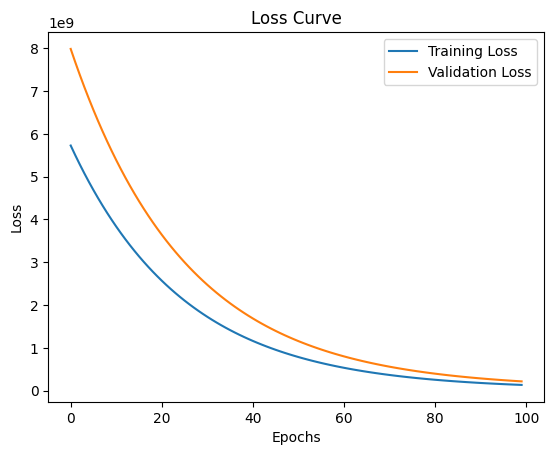

In [12]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

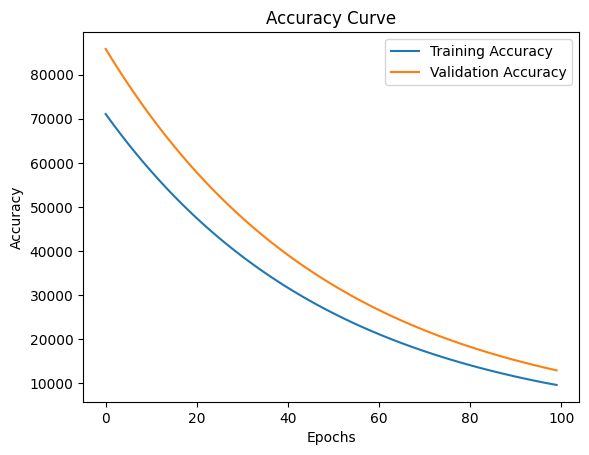

In [13]:
plt.plot(history.history['mae'], label='Training Accuracy')
plt.plot(history.history['val_mae'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [14]:
custom_input = np.array([[121872]])

In [15]:
custom_input_scaled = scaler.transform(custom_input)

In [16]:
prediction = model.predict(custom_input_scaled)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
[[9.8725824e+08]]
